In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab3.ipynb")

![](img/571_lab_banner.png)

# Lab 3: Text classification and hyperparameter optimization

<br><br>

## Imports

In [2]:
from hashlib import sha1
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">

## Submission instructions <a name="si"></a>
rubric={mechanics}

You will receive marks for correctly submitting this assignment by following the instructions below:
    
- Be sure to adhere to the [general lab instructions](https://ubc-mds.github.io/resources_pages/general_lab_instructions/).
- [Here](https://github.com/UBC-MDS/public/tree/master/rubric) you can find the description of each rubric used in MDS.
- Make at least three commits in your lab's GitHub repository.    
- Push the final .ipynb file containing your solutions to your GitHub repository for this lab.        
- Before submitting your lab, run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).  
- Ensure that you are enrolled in Gradescope through [Canvas](https://canvas.ubc.ca/courses/147081).
- Upload the .ipynb file to Gradescope and wait till your assignment to run on Gradescope.
- Verify that your plots/output are properly rendered in Gradescope.    
- If the .ipynb file is too large or doesn't render on Gradescope for any reason, also upload a pdf (preferably WebPDF) or html export of .ipynb file with your solutions so that TAs can view your submission on Gradescope. 
- Do not push or upload the data you download for this lab to your repository or Gradescope. (There is also a `.gitignore` in the repo to prevent this.)
- Below this cell, include a clickable link to your GitHub repository for the lab just below this cell.
</div>    

_Points:_ 2

YOUR REPO LINK GOES HERE

<!-- END QUESTION -->

<br><br>

## Introduction <a name="in"></a>
<hr>

In this lab, we'll focus on two things:
1. Working with text data
2. Hyperparameter optimization

As this is a quiz week, I'm skipping the worksheet section. 

## Exercise 1: Introducing the dataset and EDA <a name="1"></a>
<hr>

Let's develop our own SMS spam classification system using Kaggle's [SMS Spam Collection Dataset](https://www.kaggle.com/uciml/sms-spam-collection-dataset). The goal is to predict whether a specific text message is spam or not. 

Please download the CSV and save it as `spam.csv` locally under the `data` folder. 

> **Some text messages in this dataset may contain offensive language, a reflection of the realities on such platforms 😔. If you are sensitive to such content, please avoid reading the raw messages.** 


The starter code provided below assumes that the data file is saved as "spam.csv" and is located in the data directory of this lab folder.

In [3]:
sms_df = pd.read_csv("data/spam.csv", encoding="latin-1")
sms_df = sms_df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
sms_df = sms_df.rename(columns={"v1": "target", "v2": "sms"})
sms_df.head()

,target,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<br><br>

### 1.1 Data splitting 
rubric={autograde}

**Your tasks:**

1. Split `sms_df` into train (80%) and test (20%) splits with `random_state=123`. 

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 1

In [4]:
train_df, test_df = None, None

# BEGIN SOLUTION
train_df, test_df = train_test_split(sms_df, test_size=0.2, random_state=123)
train_df.head()
# END SOLUTION

,target,sms
385,ham,It took Mr owl 3 licks
4003,ham,Well there's a pattern emerging of my friends ...
1283,ham,Yes i thought so. Thanks.
2327,spam,URGENT! Your mobile number *************** WON...
1103,ham,Aiyah sorry lor... I watch tv watch until i fo...


In [5]:
grader.check("q1.1")

q1.1 results: All test cases passed!

<br><br>

### 1.2 Simple EDA 
rubric={autograde}

Note that traditional EDA methods for tabular data don't directly apply to text data. In this exercise, we'll conduct basic EDA to understand the data better.

**Your tasks:**

1. Calculate the average length in character count (e.g., the message 'OK' has a length of 2) for both spam and ham (non-spam) messages. Then, store the results in the appropriate variables given below.
2. Record the lengths (i.e., character counts) of the shortest and longest messages for both spam and ham in the corresponding variables provided below. 

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 3

In [6]:
avg_spam_len = None
avg_ham_len = None

# BEGIN SOLUTION
spam_messages_df = train_df[train_df["target"] == 'spam']
ham_messages_df = train_df[train_df["target"] == 'ham']
sorted_spam_df = spam_messages_df.reindex(spam_messages_df.sms.str.len().sort_values().index)
sorted_ham_df = ham_messages_df.reindex(ham_messages_df.sms.str.len().sort_values().index)
avg_spam_len = spam_messages_df.sms.str.len().mean()
avg_ham_len = ham_messages_df.sms.str.len().mean()
# END SOLUTION

In [7]:
print("Average spam length: {:.3f}".format(avg_spam_len))
print("Average spam length: {:.3f}".format(avg_ham_len))

Average spam length: 138.658
Average spam length: 70.958


In [8]:
shortest_spam_len = None
longest_spam_len = None
shortest_ham_len = None
longest_ham_len = None

# BEGIN SOLUTION
shortest_spam_len = len(sorted_spam_df.iloc[0]["sms"])
longest_spam_len = len(sorted_spam_df.iloc[-1]["sms"])
shortest_ham_len = len(sorted_ham_df.iloc[0]["sms"])
longest_ham_len = len(sorted_ham_df.iloc[-1]["sms"])
# END SOLUTION

In [9]:
print(f"Shortest spam length: {shortest_spam_len}")
print(f"Longest spam length: {longest_spam_len}")
print(f"Shortest ham length: {shortest_ham_len}")
print(f"Longest ham length: {longest_ham_len}")

Shortest spam length: 13
Longest spam length: 224
Shortest ham length: 2
Longest ham length: 790


In [10]:
grader.check("q1.2")

q1.2 results: All test cases passed!

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 Discussion 
rubric={reasoning}

**Your tasks:**

1. Discuss any observed differences in the average lengths of spam and ham messages.
2. Show the shortest and longest spam and ham messages. If multiple messages share the same length, you can choose any to showcase.
3. If we want to train supervised machine learning models on this data, how would you recommend encoding the `sms` column? Would one-hot encoding be appropriate for this column? Explain your reasoning.

<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 3

_Type your answer here, replacing this text._

In this dataset, there's a noticeable difference in the average length of spam and ham messages. Spam messages are typically longer. This might suggest that spammers tend to be more verbose, providing additional details in their messages.

In [11]:
# BEGIN SOLUTION
print('Shortest spam:',  sorted_spam_df.iloc[0]['sms'])
print('Longest spam:',  sorted_spam_df.iloc[-1]['sms'])
# END SOLUTION

Shortest spam: 2/2 146tf150p
Longest spam: Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive å£5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....


In [12]:
# BEGIN SOLUTION
print('Shortest ham:',  sorted_ham_df.iloc[0]['sms'])
print('Longest ham:',  sorted_ham_df.iloc[-1]['sms'])
# END SOLUTION

Shortest ham: Ok
Longest ham: The last thing i ever wanted to do was hurt you. And i didn't think it would have. You'd laugh, be embarassed, delete the tag and keep going. But as far as i knew, it wasn't even up. The fact that you even felt like i would do it to hurt you shows you really don't know me at all. It was messy wednesday, but it wasn't bad. The problem i have with it is you HAVE the time to clean it, but you choose not to. You skype, you take pictures, you sleep, you want to go out. I don't mind a few things here and there, but when you don't make the bed, when you throw laundry on top of it, when i can't have a friend in the house because i'm embarassed that there's underwear and bras strewn on the bed, pillows on the floor, that's something else. You used to be good about at least making the bed.


It does not make sense to apply OHE here because there are no fixed categories in this column, each value is going to be different and fairly unique. It's a free text column and bag-of-words encoding makes more sense. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 Word clouds
rubric={viz}

**Your tasks:**

1. Generate two word clouds: one for spam messages and another for ham (non-spam) messages using [the `wordcloud` package](https://github.com/amueller/word_cloud). To install it in your course's conda environment, use: ```conda install -c conda-forge wordcloud```
3. Briefly discuss your observations. 

> Avoid installing packages directly from the notebook. If you leave the installation command within the notebook, Gradescope might encounter issues processing your autograded questions.

> This package wasn't covered in our lectures. Consider checking the relevant documentation to learn how to create the word clouds.

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

_Type your answer here, replacing this text._

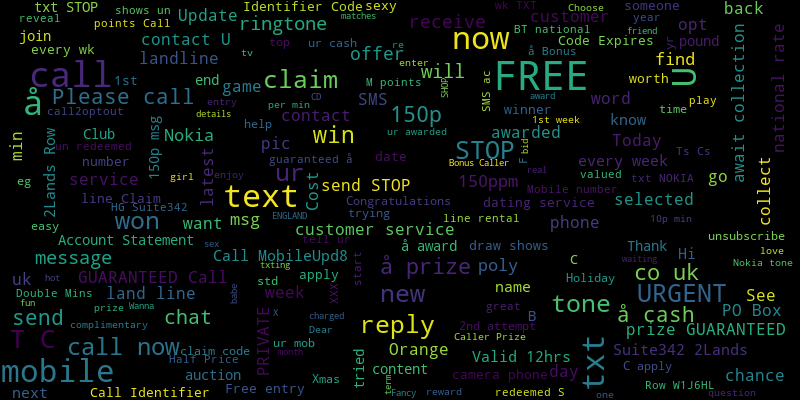

In [13]:
# BEGIN SOLUTION
spam_messages = " ".join(train_df[train_df["target"] == "spam"]["sms"].tolist())
ham_messages = " ".join(train_df[train_df["target"] == "ham"]["sms"].tolist())

from wordcloud import WordCloud

wordcloud = WordCloud(max_font_size=40, width=800, height=400)
wordcloud.generate(spam_messages).to_image()
# END SOLUTION

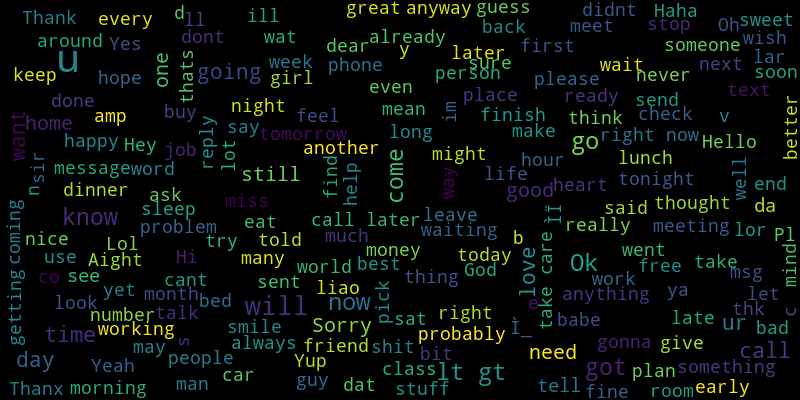

In [14]:
# BEGIN SOLUTION
wordcloud = WordCloud(max_font_size=40, width=800, height=400)
wordcloud.generate(ham_messages).to_image()
# END SOLUTION

As expected, the words such as _call, free, urgent, text, claim, prize_ are dominant in spam messages compared to non-spam messages.    

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: Model building
<hr>

## 2.1 `DummyClassifier`
rubric={autograde}

Now it's time to build models. Let's start with a baseline model. Before proceeding, remember to create `X_train`, `y_train`, `X_test`, `y_test` from `train_df` and `test_df` above.

**Your tasks:**
1. Calculate the mean cross-validation score of the `DummyClassifier` using default hyperparameters. Store the result in the `mean_cv_score` variable.

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 1

In [15]:
X_train, y_train = None, None
X_test, y_test = None, None
mean_cv_score = None

# BEGIN SOLUTION
X_train, y_train = train_df["sms"], train_df["target"]
X_test, y_test = test_df["sms"], test_df["target"]

dummy = DummyClassifier()
mean_cv_score = cross_val_score(dummy, X_train, y_train).mean()
mean_cv_score
# END SOLUTION

0.862239233390205

In [16]:
grader.check("q2.1")

q2.1 results: All test cases passed!

<br><br>

### 2.2 Running a cross-validation fold without sklearn tools 
rubric={autograde}

Sklearn provides a lot of useful tools like `make_pipeline` and `cross_validate`, which are awesome. But with these fancy tools it's also easy to lose track of what is actually happening under the hood. 

**Your tasks:**

1. Calculate the validation score for SVC on the first fold, meaning you should train on 80% and validate on the remaining 20% of the `X_train` data. Do this without using sklearn's `Pipeline`, `cross_validate`, or `cross_val_score`. Save the score from this fold in a variable named `fold_score`. Remember that cross_validation in sklearn doesn't shuffle data by default.
To begin, use the provided `CountVectorizer` and `SVC` objects, along with `X_train` and `y_train`. You'll need to further divide these using `train_test_split` with the parameter `shuffle=False`.

In [17]:
countvec_q_2_2 = CountVectorizer(stop_words="english")
svc_q_2_2 = SVC(random_state=123)

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 4

In [18]:
fold_score = None

# BEGIN SOLUTION
X_train_fold, X_valid_fold, y_train_fold, y_valid_fold = train_test_split(
    X_train, y_train, test_size=0.2, shuffle = False 
)

X_train_fold_vec = countvec_q_2_2.fit_transform(X_train_fold)
X_valid_fold_vec = countvec_q_2_2.transform(X_valid_fold)

svc_q_2_2.fit(X_train_fold_vec, y_train_fold)
fold_score = svc_q_2_2.score(X_valid_fold_vec, y_valid_fold)
# END SOLUTION

In [19]:
grader.check("q2.2")

q2.2 results: All test cases passed!

<br><br>

### 2.3 `SVC` with default hyperparameters
rubric={autograde}

Now that we know how each cross-validation fold works, let's go back to our usual sklearn tools. 

**Your tasks:**

1. Build a pipeline for feature extraction using `CountVectorizer` with `stop_words='english'` and `SVC` with `random_state=123` and default hyperparameters. Report the mean cross-validation score.

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 1

In [20]:
svc_pipe = None
mean_cv_svc = None

# BEGIN SOLUTION
svc_pipe = make_pipeline(CountVectorizer(stop_words="english"), SVC(random_state=123))
mean_cv_svc = cross_val_score(svc_pipe, X_train, y_train).mean()
mean_cv_svc
# END SOLUTION

0.9771126813727712

In [21]:
grader.check("q2.3")

q2.3 results: All test cases passed!

<br><br>

## Exercise 3: Hyperparameter optimization
<hr>

Seems like SVC is a promising model on this problem. So let's carry out hyperparameter optimization for SVC. For all the sub-parts of this question, we will be using our `svc_pipe` from the previous exercise.

So far we have been writing loops to try a bunch of different hyperparameter values and pick the one with lowest cross-validation error. This operation is so common that `scikit-learn` has some [built-in classes](https://scikit-learn.org/stable/modules/grid_search.html) to do it for you. In this exercise, we will explore two such classes:

1. [`sklearn.model_selection.GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) 
2. [`sklearn.model_selection.RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

<br><br>

<!-- BEGIN QUESTION -->

### 3.1 Optimizing `C` for SVM RBF
rubric={reasoning}

The code below carries out hyperparameter search over `C` by sweeping the hyperparameter through the values $10^{-2}, 10^{-1}, 1, 10^{1}, 10^{2}$ using [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) and 5-fold cross-validation and plots training and cross-validation curves (mean train and mean cross-validation scores for different values of `C` from the `param_grid`) with `C` on the x-axis (use log scale) and scores on the y-axis. 

**Your tasks:**

1. Identify the "optimal" hyperparameter value and its associated best cross-validation score from the search. Save these values in the specified variables.
2. Contrast this score with the one you obtained in exercise 3.3, where you used the SVC with default settings and reflect on whether selecting the parameter value with highest cross-validation score in this scenario is a reasonable choice.
   
A few tips about `GridSearchCV`: 

- The starter code below defines the parameter grid for `C` which you can pass to your `GridSearchCV`. Note the syntax `svc__C`. We have two steps in our pipeline and we can access the parameters of these steps using `__` to go deeper. So `svc__C` means `C` of `svc` step of the pipeline. 
- Setting `n_jobs=-1` should speed things up (if you have a multi-core processor).
- Similar to `cross_validate`, you can pass `return_train_score=True` to your `GridSearchCV` object.
- By default, after carrying out the search, `GridSearchCV` also refits a model with the entire training set with the best hyperparameter values. 

In [22]:
param_grid = {"svc__C": 10.0 ** np.arange(-2, 3)}

In [23]:
import matplotlib.pyplot as plt
def plot_train_cv(param_vals, train_scores, cv_scores, xlabel, ylabel="accuracy"):
    plt.semilogx(param_vals, train_scores, label="train")
    plt.semilogx(param_vals, cv_scores, label="valid")
    plt.legend()

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

In [24]:
print(
    "We are carrying out %d 5-fold cross-validation experiments"
    % (np.prod(list(map(len, param_grid.values()))))
)

C_search = GridSearchCV(
    svc_pipe, param_grid, n_jobs=-1, cv=5, return_train_score=True
)
C_search.fit(X_train, y_train)

We are carrying out 5 5-fold cross-validation experiments


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('countvectorizer',
                                        CountVectorizer(stop_words='english')),
                                       ('svc', SVC(random_state=123))]),
             n_jobs=-1,
             param_grid={'svc__C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])},
             return_train_score=True)

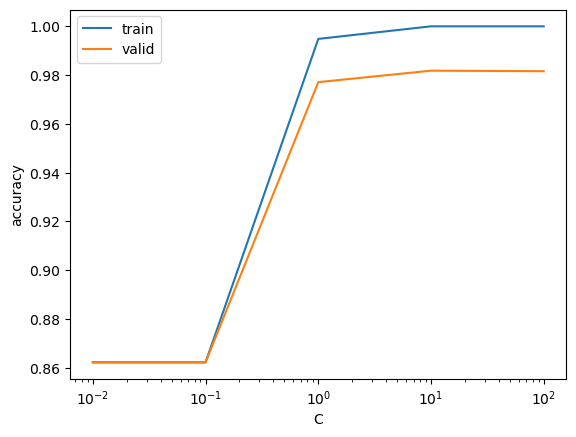

In [25]:
train_scores = C_search.cv_results_["mean_train_score"]
cv_scores = C_search.cv_results_["mean_test_score"]
plot_train_cv(param_grid["svc__C"], train_scores, cv_scores, xlabel="C")

<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [26]:
best_C = None
best_C_score = None

# BEGIN SOLUTION
best_C = C_search.best_params_['svc__C']
best_C_score = C_search.best_score_
print("Best hyperparameter values: %0.3f" % (best_C))
print("Best score: %0.3f" % (best_C_score))

# END SOLUTION

Best hyperparameter values: 10.000
Best score: 0.982


We see that for larger values of `C` the training score goes up. The gap between train and validation is not changing much after `C=1`. 

We see some improvement after hyperparameter optimization of `C` with `C=10` but the difference is not that big. So it might be a good idea to go with less complex model with `C=1`.  

<!-- END QUESTION -->

<br><br>

### 3.2 Jointly optimizing `C` and `gamma`
rubric={autograde}

Now let's optimize `C` hyperparameter along with `gamma`. 

**Your tasks:**

1. Expand your grid search to cover the `gamma` hyperparameter in addition to `C`, sweeping the hyperparameter through values $10^{-2}, 10^{-1}, \ldots, 10^{2}$ for both `C` and `gamma`. Store the information in the appropriate variables below. 

<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 4

In [27]:
param_grid = None
gamma_C_search = None
best_gamma_C = None
best_gamma_C_score = None

# BEGIN SOLUTION
param_grid = {
    "svc__gamma": 10.0 ** np.arange(-2, 3),
    "svc__C": 10.0 ** np.arange(-2, 3)
}
print(
    "We are carrying out %d 5-fold cross-validation experiments"
    % (np.prod(list(map(len, param_grid.values()))))
)

gamma_C_search = GridSearchCV(
    svc_pipe, param_grid, n_jobs=-1, return_train_score=True
)
gamma_C_search.fit(X_train, y_train)

best_gamma_C = gamma_C_search.best_params_
best_gamma_C_score = gamma_C_search.best_score_
# END SOLUTION

print("Best hyperparameter values: ", best_gamma_C)
print("Best score: %0.3f" % best_gamma_C_score)

We are carrying out 25 5-fold cross-validation experiments
Best hyperparameter values:  {'svc__C': 10.0, 'svc__gamma': 0.1}
Best score: 0.982


In [28]:
grader.check("q3.2")

q3.2 results: All test cases passed!

<br><br>

<!-- BEGIN QUESTION -->

### 3.3 Discussion
rubric={reasoning}

**Your tasks:**

1. Did the best `C` value you found in this search match what you got when only optimizing `C` in section 4.1? In a broader context, should these values necessarily align? Explain your reasoning.

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In this case, we did get the same value of `C` in both cases. But it doesn't have to be the case. A joint search over a $n$-dimensional parameter space may yield a different optimum than searching over any of those parameters individually. On a side note, we are trying more models now, so optimization bias can increase. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 3.4 Jointly optimizing SVM RBF and `CountVectorizer` hyperparameters with `RandomizedSearchCV`
rubric={accuracy,quality}

Like estimators, transformers also have hyperparameters. In this exercise, you'll jointly optimize hyperparameters of `SVC` as well as `CountVectorizer` using 
`RandomizedSearchCV`, which, as its name implies, tries random hyperparameter configurations instead of performing an exhaustive grid search. 

**Your tasks:**

1. Jointly optimize `C` and `gamma` hyperparameters for the SVC with an RBF kernel, as well as the `binary` and `max_features` hyperparameters for the `CountVectorizer`. Use [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) for this and display the best hyperparameter values and best scores found from your search. When selecting the hyperparameters, opt for reasonable value ranges or distributions, based on your discretion. You can use either a parameter grid or suitable distributions. 

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 5

In [29]:
param_dist = None

# BEGIN SOLUTION
from scipy.stats import expon, lognorm, loguniform, randint, uniform, norm, randint
param_dist = {
    "svc__C": loguniform(1e-2, 1e3),
    "svc__gamma": loguniform(1e-3, 1e3),
    "countvectorizer__max_features": randint(10, 8000),
    "countvectorizer__binary": [True, False]
}
# END SOLUTION

In [30]:
random_search = None

# BEGIN SOLUTION
random_search = RandomizedSearchCV(
    svc_pipe,
    param_dist,
    n_iter=100,
    verbose=1,
    n_jobs=-1,
    random_state=123,
    return_train_score=True
)

random_search.fit(X_train, y_train);
# END SOLUTION

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [31]:
best_params = None

# BEGIN SOLUTION
best_params = random_search.best_params_

print("Best hyperparameter values: ", best_params)
print("Best score: %0.3f" % random_search.best_score_)
pd.DataFrame(random_search.cv_results_)[
    [
        "mean_train_score",
        "mean_test_score",
        "param_svc__C",
        "param_countvectorizer__max_features",
        "param_countvectorizer__binary",
        "mean_fit_time",
        "rank_test_score"
    ]
].set_index("rank_test_score").sort_index().T
# END SOLUTION

Best hyperparameter values:  {'countvectorizer__binary': False, 'countvectorizer__max_features': 4179, 'svc__C': 828.2366121619634, 'svc__gamma': 0.03509557683522423}
Best score: 0.985


rank_test_score,1,2,3,4,5,6,7,8,9,10,...,80,80,80,80,80,80,80,80,80,80
mean_train_score,0.999888,0.999607,0.998093,1.0,0.998486,0.992989,0.993437,0.999439,0.987492,0.999439,...,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239
mean_test_score,0.984965,0.983395,0.982722,0.982049,0.981825,0.981375,0.980927,0.980029,0.979581,0.979357,...,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239,0.862239
param_svc__C,828.236612,30.036384,298.463646,653.164135,368.261466,51.20481,1.34633,98.680572,13.175429,157.114671,...,0.208883,0.016411,0.021571,0.086004,0.152405,0.370122,0.030036,0.081745,0.019879,0.101624
param_countvectorizer__max_features,4179,3397,2500,6124,2169,2694,3872,3044,1399,3092,...,5553,4446,2019,474,6246,1071,902,7995,2904,2650
param_countvectorizer__binary,False,False,False,True,False,False,True,False,True,True,...,True,False,False,False,True,True,False,True,False,False
mean_fit_time,0.345318,0.344339,0.221687,0.546379,0.177147,0.171956,0.300947,0.22162,0.166117,0.174055,...,0.748364,0.747276,0.705026,0.309855,0.798481,0.248439,0.257796,0.344993,0.434421,0.713998


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 3.5  `RandomizedSearchCV` and `GridSearchCV`
rubric={reasoning}

**Your tasks:**

1. Name a situation in which random search would be strongly preferable over a grid search, and provide a brief explanation for this preference. 

<div class="alert alert-warning">

Solution_3.5
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

`GridSearchCV` can be slow and computationally intensive when the search space is large, as it tries out every possible combination of the values and measures the model performance for that configuration. Also, when there are some unimportant hyperparameters in the grid, it wastes many searches while systematically sweeping through this unimportant hyperparameter. An approach like `RandomizedSearchCV` is preferable in such scenarios, as it tries out a given number of trails from the search space at random. Because of its random nature, it explores more parts of the search space and is less likely to waste searches caused by systematically sweeping over unimportant hyperparameters. 

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 4: Test results <a name="5"></a>
<hr>

Now that we have done extensive hyperparameter search, it's time to try our best model on the test split. 

### 4.1 Report test scores
rubric={autograde}

**Your tasks:**
1. Evaluate your top-performing model on both the training and test sets, then assign the results to the respective variables provided below.

<div class="alert alert-warning">

Solution_4.1
    
</div>

_Points:_ 1

In [32]:
best_cv_score = None
train_score = None
test_score = None

# BEGIN SOLUTION
best_cv_score = random_search.best_score_
train_score = random_search.score(X_train, y_train)
test_score = random_search.score(X_test, y_test)
# END SOLUTION

print("CV score: %0.3f" % best_cv_score)
print("Train score: %0.3f" % train_score)
print("Test score: %0.3f" % test_score)

CV score: 0.985
Train score: 1.000
Test score: 0.978


<br><br>

<!-- BEGIN QUESTION -->

### 4.2 Discussion and evaluation
rubric={reasoning}

**Your tasks:**

1. How does your test accuracy compare to your validation accuracy? Briefly comment. 
2. Try out your best model on a couple of fake spam and ham (non-spam) text messages. You can start with some sample messages given below.  
3. Do you believe that this model is likely to identify spam messages in the wild with the observed accuracy? Briefly discuss. 

<div class="alert alert-warning">

Solution_4.2
    
</div>

_Points:_ 3

In [33]:
sample_text_msgs = ["""Call 8375467843 immediately. URGENT!! 
                    You have a free gift waiting for you...""", # potential spam
                    "MDS is fun.", # potential non-spam
                    """This is very URGENT!! This week the MDS team has decided that 
                      all of you get 100% on all assignments and quizzes for free. 
                      Visit https://bit.ly/2T15k6V to check your grades.""" # potential spam                    
]

_Type your answer here, replacing this text._

In [34]:
# BEGIN SOLUTION
random_search.predict(sample_text_msgs)
# END SOLUTION

array(['spam', 'ham', 'spam'], dtype=object)

The test scores are consistent with the validation scores. So our cross-validation results seem representative of the test data and the model doesn't seem to overfit. That said, I don't believe that we have a close to perfect and a reliable system for spam identification. Our dataset is rather small and the `most_frequent` baseline for the dataset is pretty high. More rigorous evaluation, probably on some data in the wild, would give us a better picture. 

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 5: Food for thought
<hr>

Each lab will have a few challenging questions. In some labs, I will be including challenging questions which lead to the material in the upcoming week. These are usually low-risk questions and will contribute to maximum 5% of the lab grade. The main purpose here is to challenge yourself or dig deeper in a particular area. When you start working on labs, attempt all other questions before moving to these questions. If you are running out of time, please skip these questions. 

We will be more strict with the marking of these questions. There might not be model answers. If you want to get full points in these questions, your answers need to
- be thorough, thoughtful, and well-written
- provide convincing justification and appropriate evidence for the claims you make 
- impress the reader of your lab with your understanding of the material, your analytical and critical reasoning skills, and your ability to think on your own

![](img/eva-game-on.png)

<!-- BEGIN QUESTION -->

### (Challenging) 5.1
rubric={reasoning}

In the EDA we noticed that the average length of spam vs. non-spam messages is quite different yet we are not using this feature in our current model. In this exercise, you will incorporate this feature in the model. 

**Your tasks:**
1. Add a new numeric feature called `sms_length` in the modeling which represents the length of text in characters, along with the bag of words features. 
2. What's the cross-validation accuracy of SVC with default hyperparameters and only `sms_length` feature? 
3. What's the cross-validation accuracy of SVC with default hyperparameters and `sms_length` and `CountVectorizer` features together? 
4. Discuss your observations. 

<div class="alert alert-warning">
    
Solution_5.1
    
</div>

_Points:_ 1

_Type your answer here, replacing this text._

Let's add the numeric feature `sms_length`. 

In [35]:
# BEGIN SOLUTION
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
train_df['sms_length'] = train_df['sms'].str.len()
# END SOLUTION

Let's examine the results with only length feature. 

In [36]:
# BEGIN SOLUTION
pipe_len_only = make_pipeline(StandardScaler(), SVC())
cross_val_score(pipe_len_only, train_df[['sms_length']], y_train)
# END SOLUTION

array([0.8632287 , 0.88901345, 0.87093154, 0.88664422, 0.87429854])

We are getting an accuracy a bit better than the dummy classifier simply using the length feature. 

Let's find out what happens when we use both bag-of-words and length features together. 

In [37]:
# BEGIN SOLUTION
numeric_features = ['sms_length']
text_feature = 'sms'
preprocessor_both = make_column_transformer(
    (StandardScaler(), numeric_features), 
    (make_pipeline(CountVectorizer(stop_words='english'), MaxAbsScaler()), text_feature)
)

pipe_len_countvec = make_pipeline(preprocessor_both, SVC())
cross_val_score(pipe_len_countvec, train_df[['sms_length', 'sms']], y_train)
# END SOLUTION

array([0.96973094, 0.97982063, 0.95959596, 0.97530864, 0.96857464])

The accuracy is comparable to what we got with just the bag-of-words features, shown below. 

In [38]:
# BEGIN SOLUTION
text_feature = 'sms'
preprocessor_cv_only = make_column_transformer(
    (make_pipeline(CountVectorizer(stop_words='english'), MaxAbsScaler()), text_feature)
)

pipe_countvec_only = make_pipeline(preprocessor_cv_only, SVC())
cross_val_score(pipe_countvec_only, train_df[['sms']], y_train)
# END SOLUTION

array([0.97197309, 0.97421525, 0.95510662, 0.9708193 , 0.96969697])

**Observations**: Adding this new feature "sms_length" does not seem to improve the overall results. That said, it's interesting that we can get an accuracy of ~87% on this task by simply looking at which message is longer in length. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### (Challenging) 5.2
rubric={reasoning}

**Your tasks:**

There are all sorts of software packages that make hyperparameter tuning with `scikit-learn` even more automated. For example:

- [hyperopt-sklearn](https://github.com/hyperopt/hyperopt-sklearn)
- [auto-sklearn](https://github.com/automl/auto-sklearn)
- [SigOptSearchCV](https://sigopt.com/docs/overview/scikit_learn)

Give one of these a try on the task above and report your thoughts. Or, if you're even more adventurous, you could try a package that isn't tied to `scikit-learn`. There are many options for you to play around with in your ample free time:

- [TPOT](https://github.com/rhiever/tpot)
- [hyperopt](https://github.com/hyperopt/hyperopt)
- [hyperband](https://github.com/zygmuntz/hyperband)
- [SMAC](http://www.cs.ubc.ca/labs/beta/Projects/SMAC/)
- [MOE](https://github.com/Yelp/MOE)
- [pybo](https://github.com/mwhoffman/pybo)
- [spearmint](https://github.com/HIPS/Spearmint)
- [BayesOpt](https://github.com/rmcantin/bayesopt)

Note: this list isn't meant to be exhaustive. 

In other news, the [Amazon SageMaker](https://aws.amazon.com/sagemaker/) is also supposed to do hyperparameter optimization for you (among many other things it does).

<div class="alert alert-warning">
    
Solution_5.2
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br><br><br>

**Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top.**

Congratulations on finishing the homework. You made it through a challenging week! Well done 👏👏! 

![](img/eva-well-done.png)

